# Optimal transport on the upper hemisphere

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-sphere-mccann-interpolation`. It solves an equal-weight Kantorovich problem on the closed upper hemisphere for the intrinsic quadratic cost, then transports every atom along its minimizing great-circle arc.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
)
ROOT = _OT4ML_STYLE.configure_notebook(packages=_OT4ML_PACKAGES)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.optimize import linear_sum_assignment

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "monge-sphere-mccann-interpolation"
OUT = figure_dir(NAME)
THUMB_OUT = ROOT / "notebooks-figures" / "thumbnails"
THUMB_OUT.mkdir(parents=True, exist_ok=True)

## Intrinsic discrete transport

Let $x_i,y_j\in\mathbb S^2_+$ and define

$$
    C_{ij}=\frac12 d_{\mathbb S^2}(x_i,y_j)^2
    =\frac12\arccos\!\bigl(\langle x_i,y_j\rangle\bigr)^2.
$$

Both empirical measures have the same number of equal-mass atoms. Their Kantorovich polytope is therefore a rescaled Birkhoff polytope, so a linear minimizer can be chosen as a permutation coupling. We compute that optimizer with the Hungarian linear-assignment algorithm.

In [3]:
def sphere_point(longitude, latitude):
    """Convert spherical coordinates to a point on the unit upper hemisphere.

    Args:
        longitude: Longitude in radians.
        latitude: Latitude in radians, between zero and pi/2.

    Returns:
        A unit vector in R^3 with nonnegative third coordinate.
    """
    return np.array(
        [
            np.cos(latitude) * np.cos(longitude),
            np.cos(latitude) * np.sin(longitude),
            np.sin(latitude),
        ]
    )


def sphere_exponential(center, tangent):
    """Apply the exponential map of the unit sphere at one point.

    Args:
        center: Unit vector defining the base point.
        tangent: Tangent vector orthogonal to ``center``.

    Returns:
        The endpoint of the spherical geodesic with the prescribed tangent.
    """
    radius = np.linalg.norm(tangent)
    if radius < 1e-14:
        return np.asarray(center, dtype=float).copy()
    return np.cos(radius) * center + np.sin(radius) * tangent / radius


def clustered_hemisphere_points(longitude, latitude, count, phase):
    """Create a deterministic, well-spread cluster on the upper hemisphere.

    Args:
        longitude: Longitude of the cluster center in radians.
        latitude: Latitude of the cluster center in radians.
        count: Number of points in the cluster.
        phase: Angular offset used to decorrelate different clusters.

    Returns:
        An array of shape ``(count, 3)`` containing unit vectors.
    """
    center = sphere_point(longitude, latitude)
    east = np.array([-np.sin(longitude), np.cos(longitude), 0.0])
    north = np.cross(center, east)
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    points = []
    for index in range(count):
        radius = 0.07 + 0.21 * np.sqrt((index + 0.35) / count)
        angle = phase + golden_angle * index
        tangent = radius * (
            np.cos(angle) * east + 0.72 * np.sin(angle) * north
        )
        points.append(sphere_exponential(center, tangent))
    return np.asarray(points)


# With the chosen camera, longitudes below VIEW_AZIMUTH project to the
# visible left half and larger longitudes project to the visible right half.
source = np.vstack(
    [
        clustered_hemisphere_points(-1.95, 0.32, 8, 0.2),
        clustered_hemisphere_points(-1.48, 0.76, 8, 1.0),
    ]
)
target = np.vstack(
    [
        clustered_hemisphere_points(-0.45, 0.32, 8, 0.7),
        clustered_hemisphere_points(0.00, 0.78, 8, 1.6),
    ]
)

# Equal masses reduce the Kantorovich problem to a linear assignment.
pairwise_angles = np.arccos(np.clip(source @ target.T, -1.0, 1.0))
cost = 0.5 * pairwise_angles**2
rows, columns = linear_sum_assignment(cost)
permutation = np.empty(source.shape[0], dtype=int)
permutation[rows] = columns
matched_target = target[permutation]

coupling = np.zeros_like(cost)
coupling[rows, columns] = 1.0 / source.shape[0]
assert np.allclose(coupling.sum(axis=0), 1.0 / source.shape[0])
assert np.allclose(coupling.sum(axis=1), 1.0 / source.shape[0])
print(f"mean intrinsic transport cost: {np.sum(coupling * cost):.4f}")

mean intrinsic transport cost: 0.7448


## Great-circle McCann interpolation

For each optimal pair $(x_i,y_{\sigma(i)})$, put

$$
    \vartheta_i=\arccos\!\bigl(\langle x_i,y_{\sigma(i)}\rangle\bigr).
$$

The constant-speed minimizing geodesic is the spherical linear interpolation

$$
    \gamma_i(t)
    =\frac{\sin((1-t)\vartheta_i)}{\sin\vartheta_i}x_i
    +\frac{\sin(t\vartheta_i)}{\sin\vartheta_i}y_{\sigma(i)},
    \qquad
    \alpha_t=\frac1n\sum_{i=1}^n\delta_{\gamma_i(t)}.
$$

Because all endpoints lie in the upper hemisphere and the two sine weights are nonnegative, every interpolated point remains there. The numerical checks below also verify unit norm and both endpoint conditions.

In [4]:
def spherical_geodesic(source_points, target_points, times):
    """Evaluate shortest great-circle interpolants for matched point pairs.

    Args:
        source_points: Array of shape ``(n, 3)`` of unit source vectors.
        target_points: Array of shape ``(n, 3)`` of matched unit target vectors.
        times: Scalar or one-dimensional array of interpolation times in [0, 1].

    Returns:
        An array of shape ``(k, n, 3)``, where ``k`` is the number of times.
    """
    source_points = np.asarray(source_points, dtype=float)
    target_points = np.asarray(target_points, dtype=float)
    times = np.atleast_1d(np.asarray(times, dtype=float))
    angles = np.arccos(
        np.clip(np.sum(source_points * target_points, axis=1), -1.0, 1.0)
    )
    sine_angles = np.sin(angles)
    if np.any(sine_angles < 1e-10):
        raise ValueError("The interpolation requires distinct, non-antipodal pairs.")
    source_weights = np.sin((1.0 - times[:, None]) * angles[None, :]) / sine_angles
    target_weights = np.sin(times[:, None] * angles[None, :]) / sine_angles
    return (
        source_weights[..., None] * source_points[None, ...]
        + target_weights[..., None] * target_points[None, ...]
    )


plot_times = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
interpolated = spherical_geodesic(source, matched_target, plot_times)

# The positive sine coefficients keep every trajectory in the upper hemisphere.
dense_times = np.linspace(0.0, 1.0, 201)
dense_interpolated = spherical_geodesic(source, matched_target, dense_times)
assert np.allclose(np.linalg.norm(dense_interpolated, axis=2), 1.0)
assert dense_interpolated[..., 2].min() >= -1e-12
assert np.allclose(interpolated[0], source)
assert np.allclose(interpolated[-1], matched_target)
print(f"minimum latitude coordinate along all paths: {dense_interpolated[..., 2].min():.4f}")

minimum latitude coordinate along all paths: 0.1286


## Rendering

The thin violet great-circle arcs show the fixed optimal coupling. Hollow red and blue markers retain the two endpoint measures as references. Filled particles move from red to blue at $t=0,1/4,1/2,3/4,1$.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


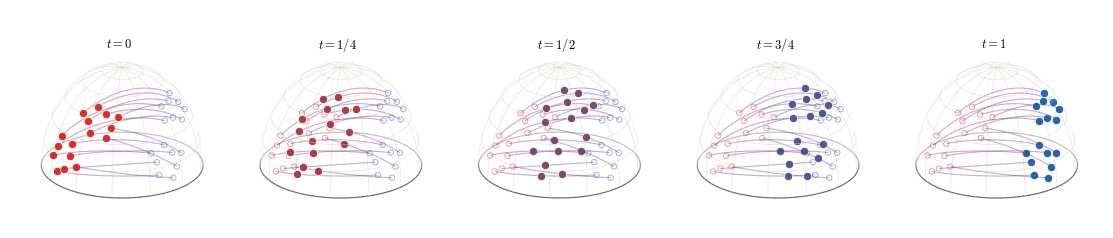

wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/monge-sphere-mccann-interpolation/evolution.pdf
thumbnail /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/monge-sphere-mccann-interpolation.png


In [5]:
VIEW_ELEVATION = 24.0
VIEW_AZIMUTH = -62.0


def add_depth_cued_curve(
    ax,
    points,
    *,
    color,
    linewidth,
    front_alpha,
    back_alpha,
):
    """Draw a spherical polyline with weaker segments on the rear hemisphere.

    Args:
        ax: Matplotlib three-dimensional axes receiving the curve.
        points: Array of shape ``(k, 3)`` containing consecutive curve points.
        color: Matplotlib color used for every segment.
        linewidth: Width of the polyline in points.
        front_alpha: Opacity for segments facing the camera.
        back_alpha: Opacity for segments on the rear side.

    Returns:
        The added three-dimensional line collection.
    """
    points = np.asarray(points, dtype=float)
    segments = np.stack([points[:-1], points[1:]], axis=1)
    midpoints = segments.mean(axis=1)
    midpoints /= np.linalg.norm(midpoints, axis=1, keepdims=True)
    elevation = np.deg2rad(VIEW_ELEVATION)
    azimuth = np.deg2rad(VIEW_AZIMUTH)
    camera_direction = np.array(
        [
            np.cos(elevation) * np.cos(azimuth),
            np.cos(elevation) * np.sin(azimuth),
            np.sin(elevation),
        ]
    )
    facing = midpoints @ camera_direction
    visibility = 0.5 * (1.0 + np.tanh(5.0 * facing))
    alphas = back_alpha + (front_alpha - back_alpha) * visibility
    colors = np.tile(to_rgba(color), (segments.shape[0], 1))
    colors[:, 3] = alphas
    collection = Line3DCollection(
        segments,
        colors=colors,
        linewidths=linewidth,
    )
    ax.add_collection3d(collection)
    return collection


def draw_upper_hemisphere(ax):
    """Draw a depth-cued latitude-longitude grid on the upper hemisphere.

    Args:
        ax: Matplotlib three-dimensional axes receiving the grid.

    Returns:
        None. The axes are modified in place.
    """
    longitude = np.linspace(-np.pi, np.pi, 220)
    for latitude in np.linspace(0.0, np.pi / 2.0, 7):
        curve = np.column_stack(
            [
                np.cos(latitude) * np.cos(longitude),
                np.cos(latitude) * np.sin(longitude),
                np.full_like(longitude, np.sin(latitude)),
            ]
        )
        add_depth_cued_curve(
            ax,
            curve,
            color=LIGHT_GRAY,
            linewidth=0.42,
            front_alpha=0.70,
            back_alpha=0.16,
        )
    latitude = np.linspace(0.0, np.pi / 2.0, 100)
    for fixed_longitude in np.linspace(-np.pi, np.pi, 13, endpoint=False):
        curve = np.column_stack(
            [
                np.cos(latitude) * np.cos(fixed_longitude),
                np.cos(latitude) * np.sin(fixed_longitude),
                np.sin(latitude),
            ]
        )
        add_depth_cued_curve(
            ax,
            curve,
            color=LIGHT_GRAY,
            linewidth=0.42,
            front_alpha=0.70,
            back_alpha=0.16,
        )
    equator = np.column_stack(
        [np.cos(longitude), np.sin(longitude), np.zeros_like(longitude)]
    )
    add_depth_cued_curve(
        ax,
        equator,
        color=GRAY,
        linewidth=0.82,
        front_alpha=0.88,
        back_alpha=0.34,
    )
    ax.set(xlim=(-1.02, 1.02), ylim=(-1.02, 1.02), zlim=(-0.02, 1.03))
    ax.set_box_aspect((1.0, 1.0, 0.68), zoom=1.15)
    ax.view_init(elev=VIEW_ELEVATION, azim=VIEW_AZIMUTH)
    ax.set_proj_type("ortho")
    ax.set_axis_off()


path_times = np.linspace(0.0, 1.0, 120)
transport_paths = spherical_geodesic(source, matched_target, path_times)


def draw_transport_panel(ax, time, current_points, title):
    """Draw one McCann snapshot over the fixed intrinsic optimal coupling.

    Args:
        ax: Matplotlib three-dimensional axes receiving the panel.
        time: Interpolation time used to color the moving atoms.
        current_points: Array of shape ``(n, 3)`` of interpolated atoms.
        title: Math-text title displayed above the panel.

    Returns:
        None. The axes are modified in place.
    """
    draw_upper_hemisphere(ax)
    for atom_path in np.swapaxes(transport_paths, 0, 1):
        add_depth_cued_curve(
            ax,
            atom_path,
            color=VIOLET,
            linewidth=0.72,
            front_alpha=0.48,
            back_alpha=0.22,
        )
    ax.scatter(
        source[:, 0],
        source[:, 1],
        source[:, 2],
        s=15,
        facecolors="none",
        edgecolors=RED,
        linewidths=0.68,
        alpha=0.48,
        depthshade=False,
    )
    ax.scatter(
        target[:, 0],
        target[:, 1],
        target[:, 2],
        s=15,
        facecolors="none",
        edgecolors=BLUE,
        linewidths=0.68,
        alpha=0.48,
        depthshade=False,
    )
    ax.scatter(
        current_points[:, 0],
        current_points[:, 1],
        current_points[:, 2],
        s=35,
        color=interp_color(time),
        edgecolors="white",
        linewidths=0.52,
        depthshade=False,
    )
    ax.text2D(
        0.5,
        0.84,
        title,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9.0,
    )


time_titles = [r"$t=0$", r"$t=1/4$", r"$t=1/2$", r"$t=3/4$", r"$t=1$"]
fig = plt.figure(figsize=(11.1, 2.30), facecolor="white")
grid = fig.add_gridspec(
    1,
    5,
    left=0.004,
    right=0.996,
    bottom=0.0,
    top=0.95,
    wspace=-0.035,
)
for panel, (time, points, title) in enumerate(
    zip(plot_times, interpolated, time_titles)
):
    axes = fig.add_subplot(grid[0, panel], projection="3d")
    draw_transport_panel(axes, time, points, title)

save_pdf(fig, OUT / "evolution.pdf", pad_inches=0.025)
fig.savefig(
    THUMB_OUT / f"{NAME}.png",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)
plt.show()
print(f"wrote {OUT / 'evolution.pdf'}")
print(f"thumbnail {THUMB_OUT / f'{NAME}.png'}")